In [6]:
!pip install neo4j

In [7]:
import sys
print(sys.executable)


/opt/anaconda3/envs/tp3graphml/bin/python


In [8]:
!pip show neo4j

Name: neo4j
Version: 6.0.3
Summary: Neo4j Bolt driver for Python
Home-page: https://neo4j.com/
Author: 
Author-email: "Neo4j, Inc." <drivers@neo4j.com>
License-Expression: Apache-2.0 AND Python-2.0
Location: /opt/anaconda3/envs/tp3graphml/lib/python3.12/site-packages
Requires: pytz
Required-by: 


In [9]:
from neo4j import GraphDatabase

url = "bolt://localhost:7687"
username = "neo4j"
password = "password"

# Connect to Neo4j
driver = GraphDatabase.driver(url, auth=(username, password))

In [10]:
driver

Let's define a simple encapsulation function to run a cypher query into our neo4j container 

In [11]:
def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return result.to_df()


In [12]:
run_query("""
SHOW DATABASES;
"""
)

,name,type,aliases,access,address,role,writer,requestedStatus,currentStatus,statusMessage,default,home,constituents
0,neo4j,standard,[],read-write,localhost:7687,primary,True,online,online,,True,True,[]
1,system,system,[],read-write,localhost:7687,primary,True,online,online,,False,False,[]


In [13]:
run_query("""
CREATE CONSTRAINT IF NOT EXISTS FOR (s:Stream) REQUIRE s.id IS UNIQUE;
"""
)

""


In [14]:
run_query("""
LOAD CSV WITH HEADERS FROM "https://bit.ly/3JjgKgZ" AS row
MERGE (s:Stream {id: row.id})
SET s.language = row.language
"""
)

""


In [15]:
# Load the data 
# 
run_query("""
LOAD CSV WITH HEADERS FROM "https://bit.ly/3S9Uyd8" AS row
CALL{
    WITH row
    MATCH (s:Stream {id:row.source})
    MATCH (t:Stream {id:row.target})
    MERGE (s)-[r:SHARED_AUDIENCE]->(t)
    SET r.weight = toInteger(row.weight)
} IN TRANSACTIONS
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (row) { ... }', position=<SummaryInputPosition line=3, column=1, offset=60>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 60, 'line': 3, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nLOAD CSV WITH HEADERS FROM "https://bit.ly/3S9Uyd8" AS row\nCALL{\n    WITH row\n    MATCH (s:Stream {id:row.source})\n    MATCH (t:Stream {id:row.target})\n    MERGE (s)-[r:SHARED_AUDIENCE]->(t)\n    SET r.weight = toInteger(row.weight)\n} IN TRANSACTIONS\n'


""


In [29]:
'''run_query("""
CALL gds.graph.drop('twitch')
""")'''

# I had put this code because when I execute twice the next cell, I may encoutner an error of type : " neo4j can't rewrite on a cell where's it's already written on "

'run_query("""\nCALL gds.graph.drop(\'twitch\')\n""")'

In [18]:
run_query("""
CALL gds.graph.project("twitch", "Stream", 
  {SHARED_AUDIENCE: {orientation: "UNDIRECTED", properties:["weight"]}})
"""
)

,nodeProjection,relationshipProjection,graphName,nodeCount,relationshipCount,projectMillis
0,"{'Stream': {'label': 'Stream', 'properties': {}}}","{'SHARED_AUDIENCE': {'aggregation': 'DEFAULT',...",twitch,3721,262854,257


In [19]:
# run query to create node2vec embeddings
run_query("""
CALL gds.beta.node2vec.write('twitch', 
  {embeddingDimension:8, relationshipWeightProperty:'weight',
   inOutFactor:0.5, returnFactor:1, writeProperty:'node2vec'})
"""
)

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.beta.node2vec.write is deprecated. It is replaced by gds.node2vec.write.', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.beta.node2vec.write('twitch', \n  {embeddingDimension:8, relationshipWeightProperty:'weight',\n   inOutFactor:0.5, returnFactor:1, writeProperty:'node2vec'})\n"


,nodeCount,nodePropertiesWritten,preProcessingMillis,computeMillis,writeMillis,configuration,lossPerIteration
0,3721,3721,0,8750,1446,"{'writeProperty': 'node2vec', 'walkLength': 80...",[22270534.371622156]


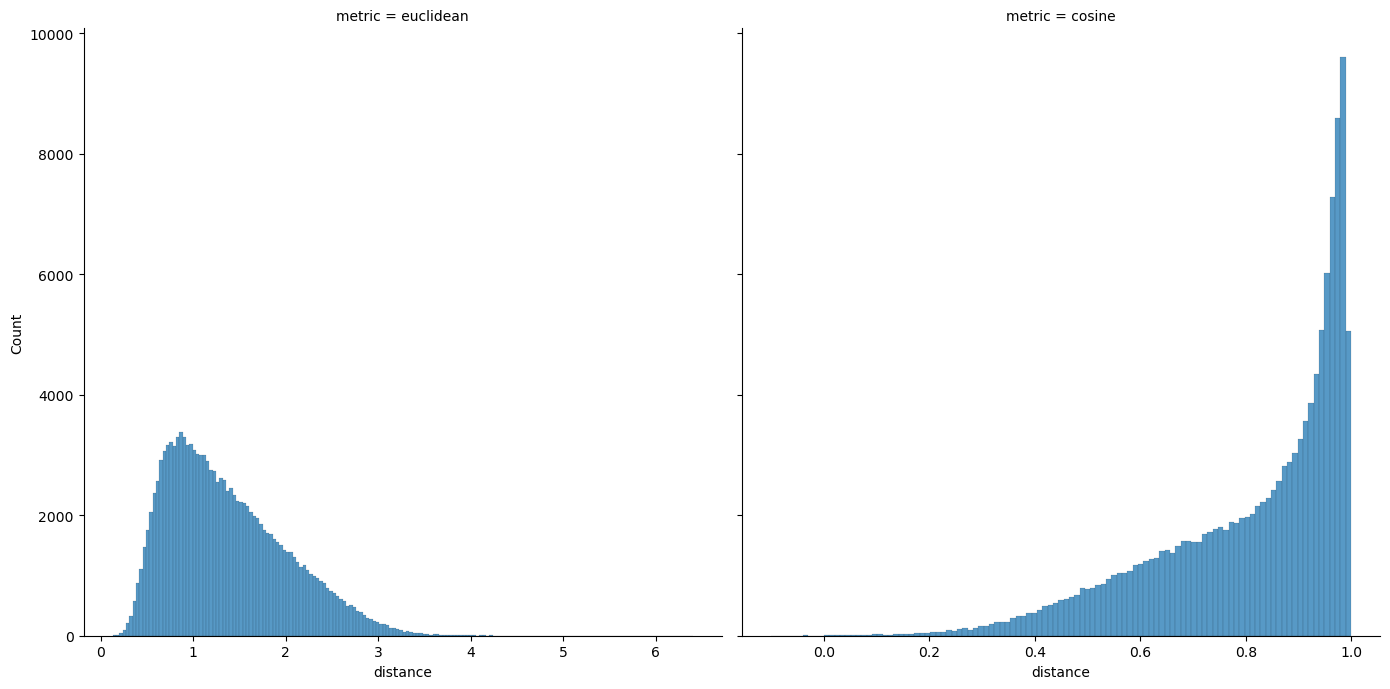

In [20]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [16, 9]
import seaborn as sns

df = run_query("""
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
RETURN gds.similarity.euclideanDistance(
   c1.node2vec, c2.node2vec) AS distance, 'euclidean' as metric
UNION
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
RETURN gds.similarity.cosine(
   c1.node2vec, c2.node2vec) AS distance, 'cosine' as metric
"""
)

sns.displot(
    data=df,
    x="distance",
    col="metric",
    common_bins=False,
    facet_kws=dict(sharex=False),
    height=7,
)

<Axes: xlabel='cosineSimilarity', ylabel='avgDegree'>

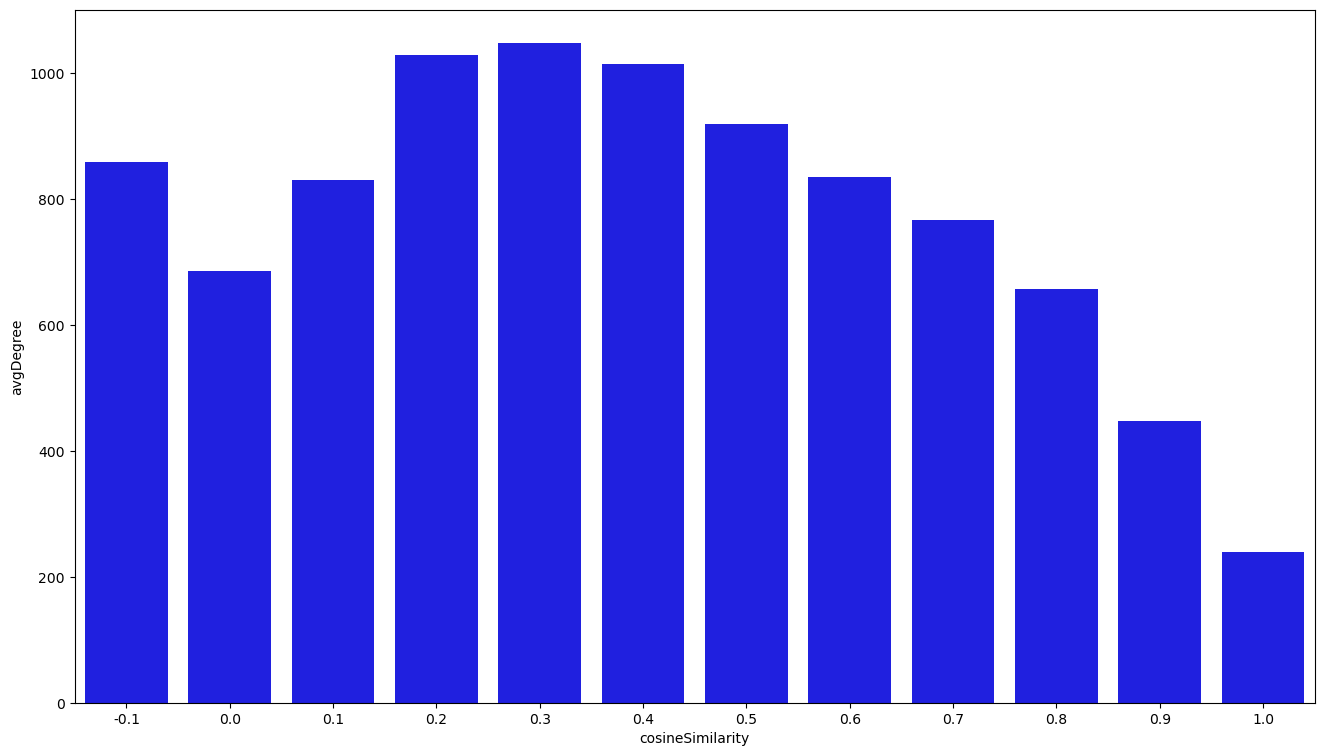

In [21]:
df = run_query("""
MATCH (c1:Stream)-[:SHARED_AUDIENCE]->(c2:Stream)
WITH c1, c2, gds.similarity.cosine(c1.node2vec, c2.node2vec) AS cosineSimilarity,
     count{ (c1)-[:SHARED_AUDIENCE]-() } AS degree1,
     count{ (c2)-[:SHARED_AUDIENCE]-() } AS degree2
RETURN round(cosineSimilarity,1) AS cosineSimilarity, avg(degree1 + degree2) AS avgDegree
ORDER BY cosineSimilarity
"""
)

sns.barplot(data=df, x="cosineSimilarity", y="avgDegree", color="blue")

<Axes: xlabel='cosineSimilarity', ylabel='avgWeight'>

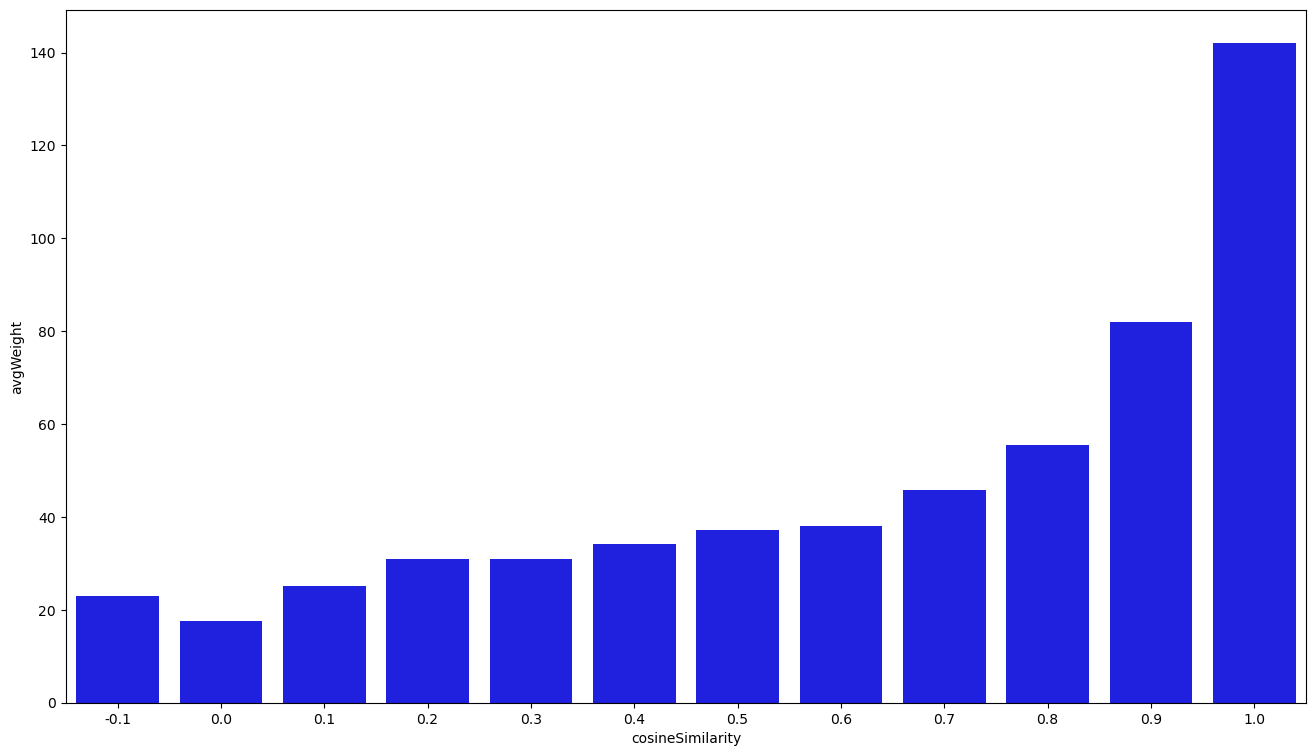

In [22]:
df = run_query("""
MATCH (c1:Stream)-[r:SHARED_AUDIENCE]->(c2:Stream)
WITH c1, c2, gds.similarity.cosine(c1.node2vec, c2.node2vec) AS cosineSimilarity,
     r.weight AS weight
RETURN round(cosineSimilarity,1) AS cosineSimilarity, avg(weight) AS avgWeight
ORDER BY cosineSimilarity
"""
)

sns.barplot(data=df, x="cosineSimilarity", y="avgWeight", color="blue")

In [23]:
import pandas as pd
data = run_query("""
MATCH (s:Stream)
RETURN s.id AS streamId, s.language AS language, s.node2vec AS embedding
"""
)
data["output"] = pd.factorize(data["language"])[0]

In [24]:
data.head()

,streamId,language,embedding,output
0,129004176,en,"[1.452094316482544, 0.2934745252132416, 1.3364...",0
1,26490481,en,"[1.339297890663147, 0.036191727966070175, 0.04...",0
2,213749122,en,"[1.2706266641616821, -0.4966552257537842, 0.30...",0
3,30104304,en,"[1.683294415473938, -0.06613384187221527, -0.4...",0
4,160504245,en,"[1.6361055374145508, -0.24163319170475006, 0.1...",0


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = data["embedding"].to_list()
y = data["output"].to_list()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
from sklearn.metrics import classification_report

y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       384
           1       0.94      0.85      0.89        54
           2       0.98      0.92      0.95        59
           3       0.82      0.85      0.84        39
           4       0.84      0.92      0.88        52
           5       0.87      0.81      0.84        58
           6       1.00      0.95      0.97        20
           7       0.92      0.96      0.94        25
           8       0.95      1.00      0.97        35
           9       0.94      0.89      0.92        19

    accuracy                           0.91       745
   macro avg       0.92      0.91      0.91       745
weighted avg       0.91      0.91      0.91       745



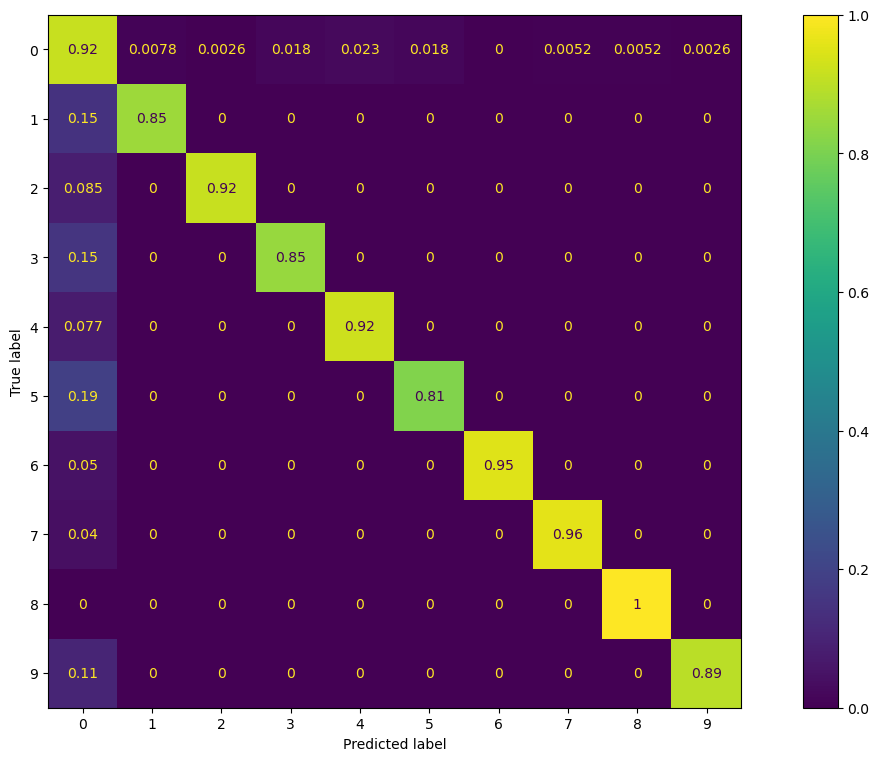

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

## Answers to questions : 

### What do you think about this matrix?

The confusion matrix shows that the model is globally good. The diagonal elements show how often the model predicted correctly for each true class. Theere are over 0.8 (between 0.82 and 1) which means most samples are correctly classified.

Several classes are classified perfectly ( Class 8 100% correct ) and Class 7 almost perfectly (96%). 

However, there are some misclassifications issue especially with class 0 where : 
* True class 1 and 3 → 15% predicted as 0
* True class 5 → 19% predicted as 0


### What is the appropriate metrics to select among the classification report to show your manager and why ?

I think the appropriate metric to show to my manager is the weighted average F-1 score because :
* Accuracy is misleading in our case since we have imbalanced dataset : Some classes have fewer samples than other so higher accuracy doesn't give better conclusions
* Precison alone and Recall alone aren't enough : Precision ignores missed detections (False Negative) and Recall ignores False alarms (False Positive) -->  F1 combines both and gives a reliable indicator 

### How can you improve the classifiers quality ?


I can imporve the classifier by : 
* balancing the training data
* Use higher dimensional feature representation 
* optimizing the model’s hyperparameters through cross-validation
* Try more advanced models to improve the performance